# **Time Series Forecasting for Financial Market Trends**

**Scenario**

Imagine you have just joined a mid-sized analytics firm where new clients regularly ask for help across diverse problem areas. In this lab, we will work through three tasks that represent common challenges faced by junior data scientists:

1. Natural Language Processing (NLP)
2. Time Series Forecasting
3. Neural Network Modeling

**In this notebook, we will be focusing on the second task: Time Series Forecasting.** We will analyze historical customer review ratings over time to understand trends, fluctuations, and patterns in the data. We will assess the stationarity of the series, apply transformations such as differencing and log transformation, and explore seasonal patterns through decomposition. Finally, we will use these findings to select appropriate forecasting models and predict future customer ratings. The goal is to understand how customer ratings change over time and use these insights to support better forecasting and decision-making.


## **Step 1: Explore and Visualize Review Activity Over Time**

### 1.1 Imports, Load and initial review

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import yfinance as yf
import warnings


# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the Amazon reviews dataset
amazon_reviews = pd.read_csv('amazon_reviews_lab.csv')

# Display the first few rows of the dataset
print("Amazon Reviews Dataset:")
print(amazon_reviews.head())

# Display basic information about the dataset
print("\nDataset information:")
print(amazon_reviews.info())

# Calculate basic summary statistics
print("\nSummary Statistics:")
print(amazon_reviews.describe())

# Check for missing values
print("\nMissing values in each column:")
print(amazon_reviews.isnull().sum())

Amazon Reviews Dataset:
   product_id  rating                                        review_text  \
0  6301977173       2  This film is definitely not for anyone who is ...   
1  6301977173       5  This movie was playing at Radio City Music Hal...   
2  6301977173       1  I would love to buy this movie as I have been ...   
3  6301977173       1  The advertisment for this DVD on Amazon was in...   
4  9575871979       5  I bought some of these to try with a light usi...   

                              review_summary review_time_raw  \
0  The best of Mark Twain's work - left out!     05 12, 2000   
1            The best Tom Sawyer i ever saw.     08 26, 2002   
2                         Why no Widescreen?      08 6, 2005   
3              False advertising on this DVD     09 11, 2005   
4                               Work GREAT!!     10 15, 2007   

   unix_review_time   timestamp sentiment_label  review_length_words  
0         958089600  12/05/2000        negative                

The dataset contains **997 Amazon customer reviews** collected between **2000 and 2014**. It includes information about the **product, customer rating, review text, sentiment, review length, and review date**. There are **no missing values**, making the dataset suitable for analysis. The average rating is **4.13 out of 5**, suggesting that customers generally gave positive ratings. The `timestamp` column, allow us to examine **changes in review activity and customer ratings over time**, which will be the focus of our time-series analysis.

### 1.2 Timestamp column anaysis.

In [ ]:
# Convert timestamp to datetime format
amazon_reviews['timestamp'] = pd.to_datetime(
    amazon_reviews['timestamp'],
    format='%d/%m/%Y'
)
# Display the first few timestamp values
print("Timestamp Data:")
print(amazon_reviews['timestamp'].head())

# Display information about the timestamp column
print("\nTimestamp information:")
print(amazon_reviews['timestamp'].info())

# Display the date range
print("\nDate range:")
print("Start date:", amazon_reviews['timestamp'].min())
print("End date:", amazon_reviews['timestamp'].max())

# Check for missing timestamps
print("\nMissing timestamps:")
print(amazon_reviews['timestamp'].isnull().sum())

# Check for duplicate timestamps
print("\nDuplicate timestamps:")
print(amazon_reviews['timestamp'].duplicated().sum())

# Display basic statistics for the timestamp
print("\nTimestamp summary:")
print(amazon_reviews['timestamp'].describe())

Timestamp Data:
0   2000-05-12
1   2002-08-26
2   2005-08-06
3   2005-09-11
4   2007-10-15
Name: timestamp, dtype: datetime64[ns]

Timestamp information:
<class 'pandas.core.series.Series'>
RangeIndex: 997 entries, 0 to 996
Series name: timestamp
Non-Null Count  Dtype         
--------------  -----         
997 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB
None

Date range:
Start date: 2000-05-12 00:00:00
End date: 2014-07-17 00:00:00

Missing timestamps:
0

Duplicate timestamps:
275

Timestamp summary:
count                              997
mean     2012-08-12 10:10:57.171514624
min                2000-05-12 00:00:00
25%                2011-07-29 00:00:00
50%                2012-12-21 00:00:00
75%                2013-09-18 00:00:00
max                2014-07-17 00:00:00
Name: timestamp, dtype: object



The **timestamp** column was initially stored as an **object (text)**, so it was converted it to **datetime64** to make it suitable for time-series analysis. The dataset has **997 timestamps with no missing values**, covering the period from **May 12, 2000, to July 17, 2014**. There are  **275 duplicate dates**, meaning that more than one review was posted on some days. This timestamp information will allow us to examine how **review activity and ratings change over time**.


### 1.3 Monthly review count and average rating

In [ ]:
# Resample the data by month
# 'ME' groups the data by month-end.

# Set timestamp as the index
amazon_reviews = amazon_reviews.set_index('timestamp')

# 1. Calculate the monthly review count
monthly_review_count = amazon_reviews['review_text'].resample('ME').count()

# 2. Calculate the monthly average rating
monthly_avg_rating = amazon_reviews['rating'].resample('ME').mean()

# Display the results
print("Monthly Review Count:")
print(monthly_review_count.head())

print("\nMonthly Average Rating:")
print(monthly_avg_rating.head())

Monthly Review Count:
timestamp
2000-05-31    1
2000-06-30    0
2000-07-31    0
2000-08-31    0
2000-09-30    0
Freq: ME, Name: review_text, dtype: int64

Monthly Average Rating:
timestamp
2000-05-31    2.0
2000-06-30    NaN
2000-07-31    NaN
2000-08-31    NaN
2000-09-30    NaN
Freq: ME, Name: rating, dtype: float64


The monthly review count shows that review activity was not evenly distributed over time. Some months contain several reviews, while other months have no reviews at all. This indicates that customer review activity fluctuated across the period rather than following a consistent pattern.

The monthly average rating also varies depending on the reviews available in each month. Months with no reviews have *NaN* values because there is no rating from which to calculate an average. For example, May 2000 had one review with an average rating of 2.0, while the following months had no recorded reviews.


We will use **two visualizations** to better understand how the time series behaves over time. The **monthly review volume graph** will help us identify changes in review activity, including increases, decreases, and periods with little or no activity. The **monthly average rating graph** will allow us to observe how customer ratings changed over time and identify any noticeable fluctuations or trends. Together, the two graphs will give us a clearer view of **review activity and customer ratings over time**.


## 1.4 Analyze Monthly Review Activity and Customer Ratings

#### 1.41 Monthly Review Volume

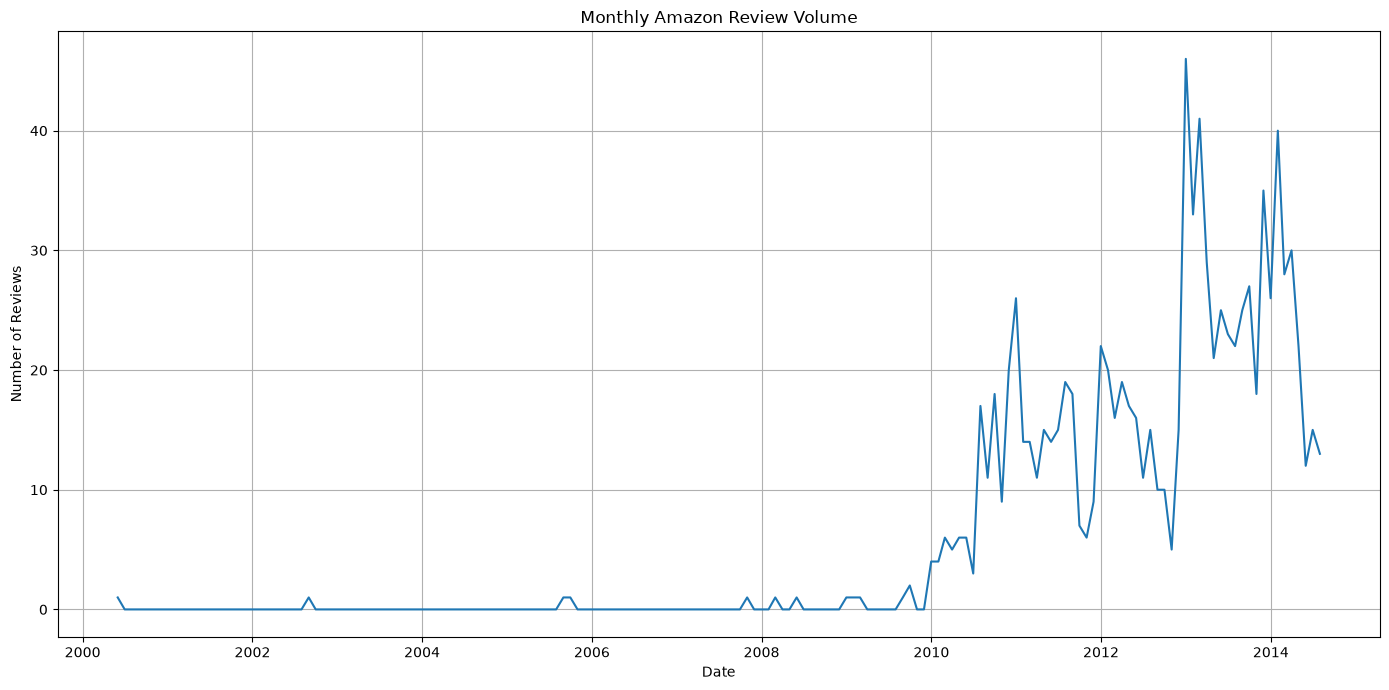

In [ ]:
# Plot monthly review volume over time
plt.figure(figsize=(14, 7))

plt.plot(monthly_review_count.index, monthly_review_count.values)

plt.title('Monthly Amazon Review Volume')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1.42 Plot Monthly Average Rating

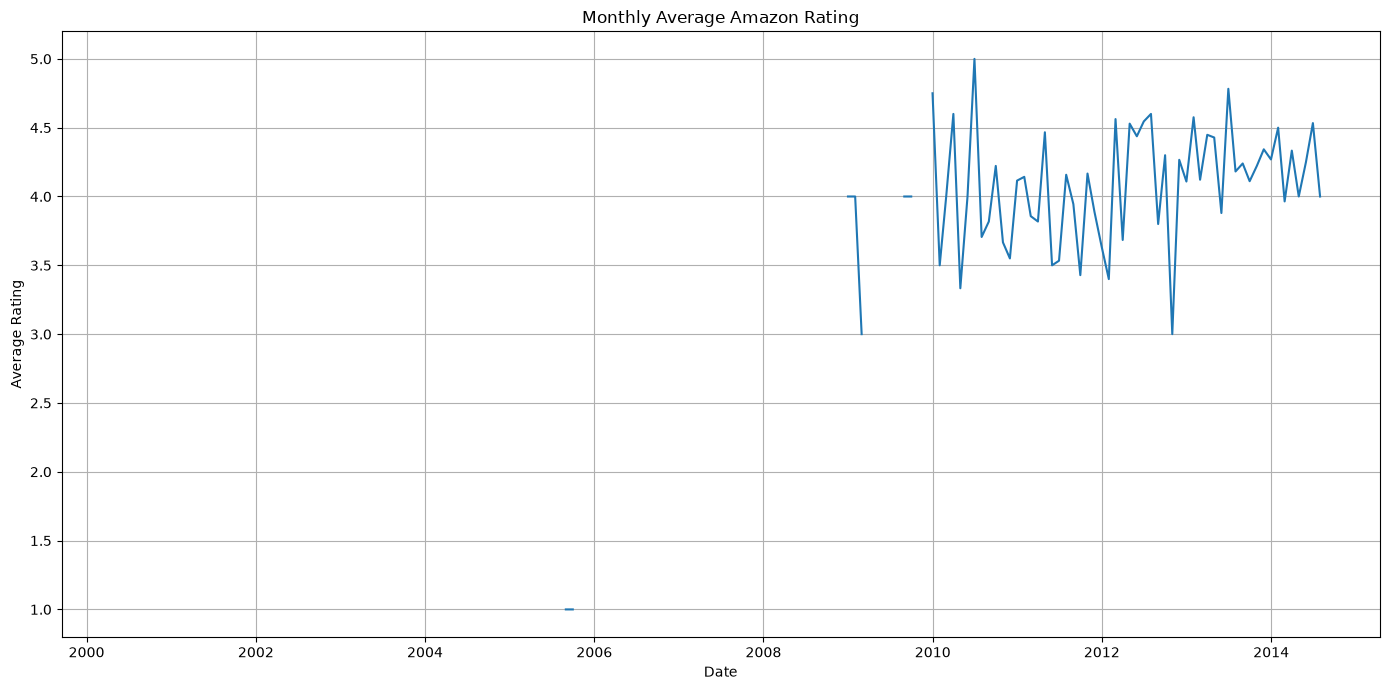

In [ ]:
# Plot monthly average rating over time
plt.figure(figsize=(14, 7))

plt.plot(monthly_avg_rating.index, monthly_avg_rating.values)

plt.title('Monthly Average Amazon Rating')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

**Overall Trends in Review Activity and Customer Ratings**

Review activity was very low before 2010, with only a few isolated observations. From 2010 onward, review volume increased steadily, reaching its highest levels around 2013–2014. During the earlier period, ratings fluctuated more widely, ranging from about 3.0 to 5.0.

As review activity increased, customer ratings became more stable and generally remained between **4.0 and 4.5**. This suggests that higher review volumes provided a more consistent picture of customer satisfaction, while low review volumes caused greater fluctuations in monthly averages.

**Conclusion:** Overall, review activity increased over time while customer ratings became more stable and consistently positive.


## **Step 2: Check Stationarity and Apply Transformations**

### 2.1 Rolling Average of Monthly Ratings - 3-month


A rolling average helps us smooth out short-term fluctuations in the monthly ratings so we can see the underlying trend more clearly. We will use a 3-month window, meaning each value will represent the average rating across the current month and the previous two months.

In [ ]:
# Calculate the 3-month rolling average
rolling_avg_rating = monthly_avg_rating.rolling(window=3).mean()

# Display the results
print("3-Month Rolling Average Rating:")
print(rolling_avg_rating.head(10))

3-Month Rolling Average Rating:
timestamp
2000-05-31   NaN
2000-06-30   NaN
2000-07-31   NaN
2000-08-31   NaN
2000-09-30   NaN
2000-10-31   NaN
2000-11-30   NaN
2000-12-31   NaN
2001-01-31   NaN
2001-02-28   NaN
Freq: ME, Name: rating, dtype: float64


Since early months have many NaN values due to no reviews, the rolling average remains NaN.

However, for the dataset, there are enough gaps that this approach may not give useful results early on.

**For results lets try from 2010 and see**

Since we want to smooth the actual months where ratings exist, we can start from 2010 were we  started having actions to calculate the 3-month rolling average:

In [ ]:
# Keep monthly ratings from 2010 onwards
monthly_avg_rating_2010 = monthly_avg_rating[monthly_avg_rating.index >= '2010-01-01']

# Calculate the 3-month rolling average
rolling_avg_rating = monthly_avg_rating_2010.rolling(window=3).mean()

# Display the results
print("3-Month Rolling Average Rating from 2010:")
print(rolling_avg_rating.head(10))

3-Month Rolling Average Rating from 2010:
timestamp
2010-01-31         NaN
2010-02-28         NaN
2010-03-31    4.033333
2010-04-30    3.977778
2010-05-31    3.977778
2010-06-30    4.111111
2010-07-31    4.235294
2010-08-31    4.174688
2010-09-30    3.915429
2010-10-31    3.902357
Freq: ME, Name: rating, dtype: float64



The 3-month rolling average shows that the average rating was relatively stable around **4.0–4.2** during 2010. It increased from **4.03 in March** to a peak of about **4.24 in July**, before declining to **3.90 by October**.

The first two months are `NaN` because a 3-month rolling average requires three months of observations.

**Conclusion:** The rolling average helps smooth short-term fluctuations and makes the underlying movement in customer ratings easier to see.


### 2.2 Original monthly average rating and the rolling average

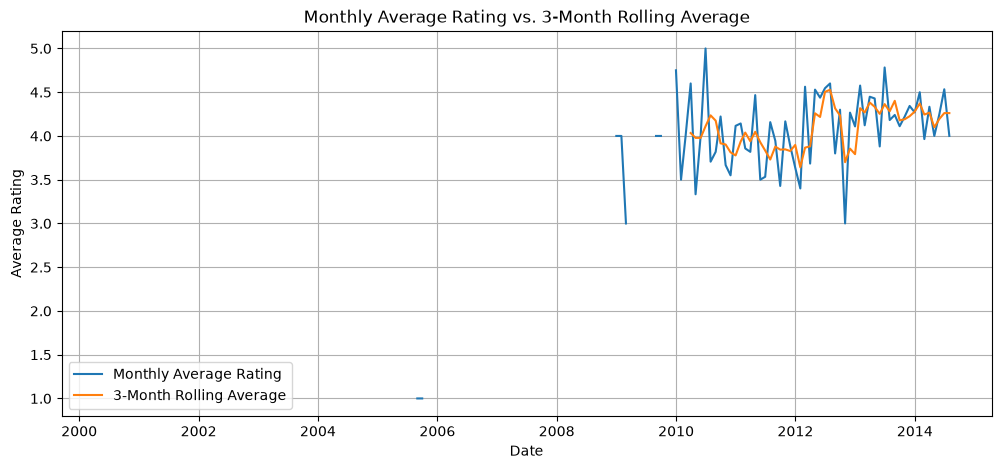

In [ ]:
# Plot original monthly average rating and 3-month rolling average

plt.figure(figsize=(12, 5))

plt.plot(monthly_avg_rating.index, monthly_avg_rating.values, label="Monthly Average Rating")
plt.plot(rolling_avg_rating.index, rolling_avg_rating.values, label="3-Month Rolling Average")

plt.title("Monthly Average Rating vs. 3-Month Rolling Average")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(True)

plt.show()

This line graph tracks monthly review ratings from 2000 to 2014 by comparing individual monthly averages against a smoother 3-month rolling trend. The dataset is nearly empty for the first decade, showing almost no activity until a continuous stream of data begins around late 2009. Once consistent tracking starts, the blue monthly ratings line swings wildly between 3.0 and 5.0, while the orange rolling average line filters out this noise to reveal a steady upward trajectory climbing from 4.0 to roughly 4.3 by 2014.

This clear upward growth highlights why stationarity is crucial for time series models. Because the data has a visible trend and shifting averages over time, it is non-stationary, meaning its statistical properties are constantly changing. Standard forecasting models cannot make reliable predictions on this raw data because they require stationarity—a constant mean and variance—to ensure past patterns accurately reflect future behavior without creating fake mathematical relationships.

### 2.3 Augmented Dickey-Fuller test

In [ ]:
# Augmented Dickey-Fuller test
adf_result = adfuller(monthly_avg_rating.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -1.4556884669077395
p-value: 0.5553067746051662


The ADF test gives a **p-value of 0.5553**, which is greater than 0.05. Therefore, we conclude that the monthly rating series is **not stationary**.

To address this, we will apply transformations, including **differencing and log transformation**, to examine their effects on the trend and variance and determine whether they improve stationarity.


### 2.4 Applying differencing

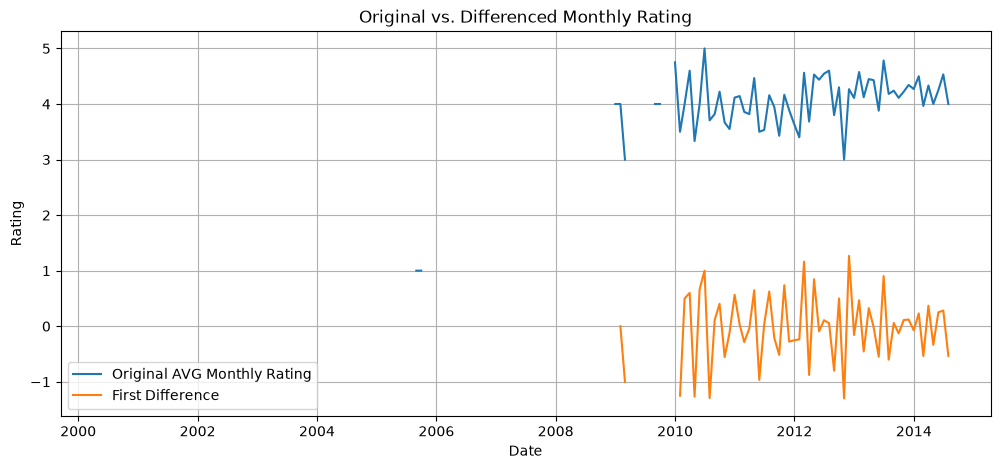

Original variance: 0.520605450434797
Differenced variance: 0.3739587875359154


In [ ]:
# First-order differencing
rating_diff = monthly_avg_rating.diff()

# Plot original and differenced series
plt.figure(figsize=(12, 5))

plt.plot(monthly_avg_rating, label="Original AVG Monthly Rating")
plt.plot(rating_diff, label="First Difference")

plt.title("Original vs. Differenced Monthly Rating")
plt.xlabel("Date")
plt.ylabel("Rating")
plt.legend()
plt.grid(True)

plt.show()

print("Original variance:", monthly_avg_rating.var())
print("Differenced variance:", rating_diff.var())

The reduction in variance from 0.5206 to 0.3739 confirms that differencing successfully removed a non-stationary trend from the dataset. By subtracting each data point from the previous one, you stabilized the mean and stripped away the long-term upward drift seen in the graph, resulting in a more uniform, stationary series.

### 2.5 Applying Log transformation


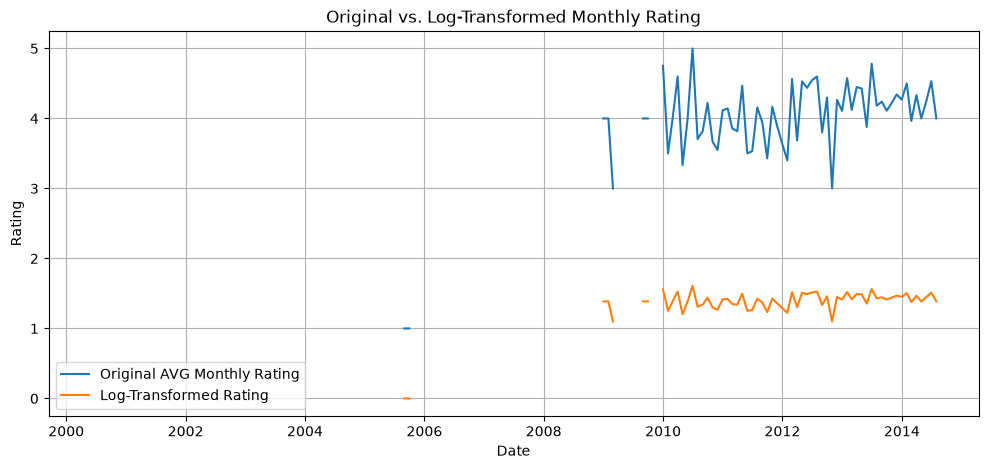

Original variance: 0.520605450434797
Log-transformed variance: 0.07522411365883945


In [ ]:
# Apply log transformation
rating_log = np.log(monthly_avg_rating)

# Plot original and log-transformed series
plt.figure(figsize=(12, 5))

plt.plot(monthly_avg_rating, label="Original AVG Monthly Rating")
plt.plot(rating_log, label="Log-Transformed Rating")

plt.title("Original vs. Log-Transformed Monthly Rating")
plt.xlabel("Date")
plt.ylabel("Rating")
plt.legend()
plt.grid(True)

plt.show()

print("Original variance:", monthly_avg_rating.var())
print("Log-transformed variance:", rating_log.var())

The dramatic drop in variance from 0.5206 to 0.0752 demonstrates that a log transformation successfully stabilized the volatility in the dataset. While the original graph shows wide, erratic swings between 3.0 and 5.0, taking the logarithm compressed these large magnitudes, smoothing out the severe fluctuations

## **Step 3: Decompose and Diagnose Patterns**

### 3.1 Decomposition & Seasonality

Next is to decompose the monthly customer ratings into trend, seasonal, and residual components to identify long-term movements, recurring yearly patterns, and random fluctuations.

<Figure size 1200x1000 with 0 Axes>

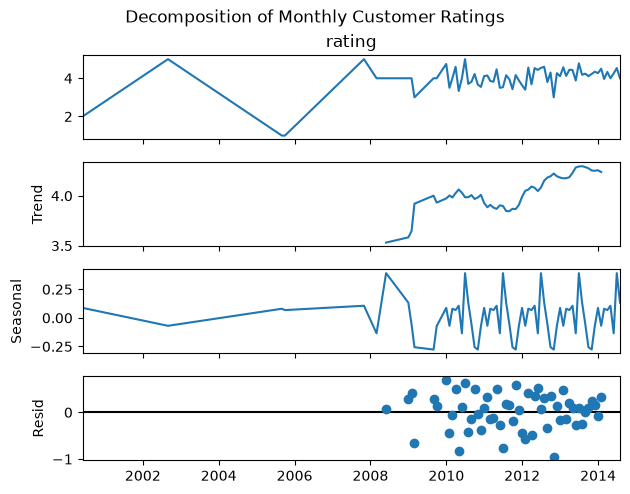

In [ ]:
# Decompose the monthly rating series
decomposition = seasonal_decompose(
    monthly_avg_rating.dropna(),
    model="additive",
    period=12
)

# Set the figure size
plt.figure(figsize=(12, 10))

# Plot the decomposition
decomposition.plot()

plt.suptitle("Decomposition of Monthly Customer Ratings", y=1.02)
plt.show()

### Decomposition and Modeling Decisions

* **Rating (Raw Data):** The original series shows monthly ratings fluctuating mainly between 3.0 and 5.0, with noticeable short-term changes. Meaning the model should capture short-term changes rather than relying only on the overall average.

* **Trend:** The trend shows the overall direction of customer ratings over time, with ratings generally increasing from around 4.0 toward 4.3.The steady upward direction suggests that **differencing** may be needed to make the series stationary.

* **Seasonal:** The seasonal component shows recurring patterns across the year, suggesting that some changes in ratings may follow a yearly cycle.This suggests that **seasonal terms** should be considered. A seasonal model such as **SARIMA** may be appropriate if the seasonal pattern is strong.

* **Residual:** The residual component shows the random fluctuations remaining after removing the trend and seasonal effects. The points are mostly scattered around zero, indicating no strong remaining pattern.It suggesting that the trend and seasonal components explain much of the systematic variation.

**Modeling Decision:** The decomposition suggests using a model that can handle **both differencing and seasonality**, with **SARIMA or ARIMA** being a suitable model to investigate.


## **Step 4: Model Selection and Diagnostics**

### 4.1 ACF and PACF Analysis
We will use ACF and PACF plots to examine the autocorrelation in the monthly ratings and determine suitable AR, MA, or ARIMA model parameters.

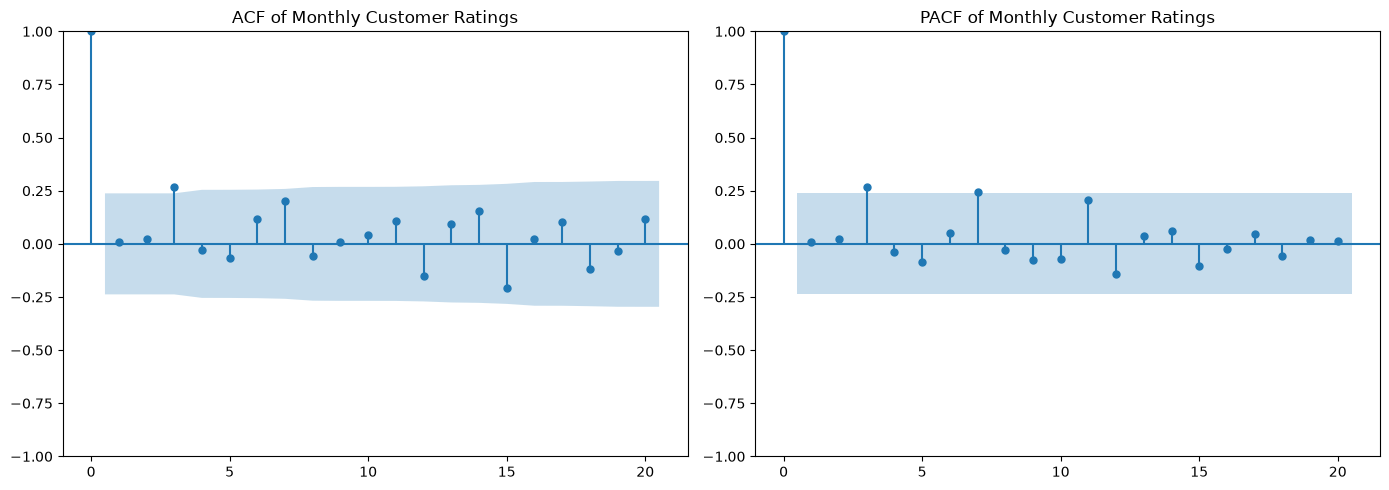

In [ ]:
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(monthly_avg_rating.dropna(), lags=20, ax=axes[0])
axes[0].set_title("ACF of Monthly Customer Ratings")

plot_pacf(monthly_avg_rating.dropna(), lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Monthly Customer Ratings")

plt.tight_layout()
plt.show()

**ACF and PACF Interpretation**

The ACF and PACF plots show the autocorrelation patterns in the monthly customer ratings and help identify suitable ARIMA model parameters.

* **ACF:** Most spikes after Lag 0 fall within the confidence interval, indicating weak autocorrelation between the current rating and previous months.
* **PACF:** Most spikes also fall within the confidence interval, suggesting limited direct autoregressive relationships between the ratings and their previous values.
* **Model Interpretation:** Since there are no strong or consistent spikes at the early lags, the series does not show a strong AR or MA pattern. Therefore, we will test simple ARIMA models with low-order parameters and compare them using AIC/BIC before selecting the best model.


### 4.2 Fit Multiple ARIMA Candidate Models
Based on our ACF/PACF results, there is no strong AR or MA pattern, so we should start with simple, low-order ARIMA models. Since the ADF test showed the series is non-stationary, we will use d = 1. Then use AIC and BIC to identify the best candidate.

In [ ]:
# Use the monthly rating series
series = monthly_avg_rating.dropna()

# Candidate ARIMA models - (p, d, q)
# p (AR order): Number of previous observations used to model the current value.
# d (differencing): Number of times the series is differenced to make it stationary.
# q (MA order): Number of previous forecast errors used in the model.
models = {
    "ARIMA(1,1,0)": (1,1,0), # 1 AR terms + 1 difference + 0 MA terms. ()
    "ARIMA(0,1,1)": (0,1,1),
    "ARIMA(1,1,1)": (1,1,1),
    "ARIMA(2,1,0)": (2,1,0),
    "ARIMA(0,1,2)": (0,1,2)
}

# Store fitted models
results = {}

# Fit each candidate model
for name, order in models.items():
    model = ARIMA(series, order=order)
    fitted_model = model.fit()

    results[name] = fitted_model

    print(f"{name}")
    print(f"AIC: {fitted_model.aic:.2f}")
    print(f"BIC: {fitted_model.bic:.2f}")
    print("-" * 30)

ARIMA(1,1,0)
AIC: 175.02
BIC: 179.43
------------------------------
ARIMA(0,1,1)
AIC: 149.74
BIC: 154.15
------------------------------
ARIMA(1,1,1)
AIC: 150.80
BIC: 157.42
------------------------------
ARIMA(2,1,0)
AIC: 148.88
BIC: 155.50
------------------------------
ARIMA(0,1,2)
AIC: 150.33
BIC: 156.95
------------------------------


These results are clear. **ARIMA(2,1,0)** is the best candidate because it has the lowest AIC (**148.88**) and a very competitive BIC (**155.50**).

### Model Comparison

* **ARIMA(1,1,0):** AIC 175.02, BIC 179.43 → weakest model
* **ARIMA(0,1,1):** AIC 149.74, BIC 154.15
* **ARIMA(1,1,1):** AIC 150.80, BIC 157.42
* **ARIMA(2,1,0):** **AIC 148.88, BIC 155.50 → best overall**
* **ARIMA(0,1,2):** AIC 150.33, BIC 156.95

### Interpretation

> **ARIMA(2,1,0) achieved the lowest AIC of 148.88, making it the best candidate based on overall model fit. ARIMA(0,1,1) had the lowest BIC at 154.15, but ARIMA(2,1,0) had the lowest AIC and a similar BIC. We will therefore select ARIMA(2,1,0) and check its residual diagnostics before forecasting.**


### 4.3 Residual Diagnostics
we are now checking the residuals of our selected ARIMA(2,1,0) model. To see whether the model has captured the important patterns in the data.

In [ ]:
# Fit the selected ARIMA(2,1,0) model
series = monthly_avg_rating.dropna()

best_model = ARIMA(series, order=(2, 1, 0)).fit()

print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 rating   No. Observations:                   68
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 -71.442
Date:                Sun, 13 Sep 2026   AIC                            148.883
Time:                        19:50:27   BIC                            155.497
Sample:                             0   HQIC                           151.500
                                 - 68                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7241      0.053    -13.622      0.000      -0.828      -0.620
ar.L2         -0.6806      0.043    -15.995      0.000      -0.764      -0.597
sigma2         0.4834      0.059      8.182      0.0

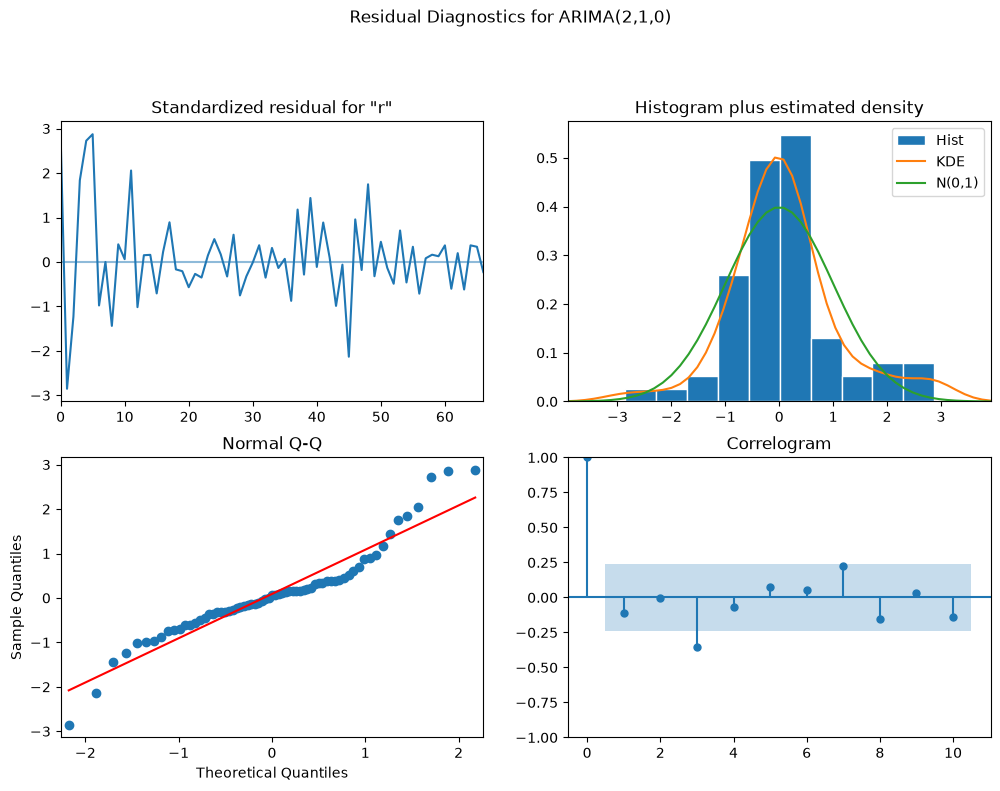

In [ ]:
# Residual diagnostics for the selected ARIMA(2,1,0) model

best_model.plot_diagnostics(figsize=(12, 8))

plt.suptitle("Residual Diagnostics for ARIMA(2,1,0)", y=1.02)
plt.show()

A significant residual autocorrelation at Lag 3 suggests that ARIMA(2,1,0) has not fully captured the dependence structure. The appropriate next step is to test another candidate model, rather than assuming ARIMA(3,1,0) will automatically be better.

### 4.4 Testing another candidate model

In [ ]:
# Fit ARIMA(3,1,0)
model_310 = ARIMA(series, order=(3, 1, 0))
fitted_310 = model_310.fit()

print("ARIMA(3,1,0)")
print("AIC:", round(fitted_310.aic, 2))
print("BIC:", round(fitted_310.bic, 2))

ARIMA(3,1,0)
AIC: 148.58
BIC: 157.4


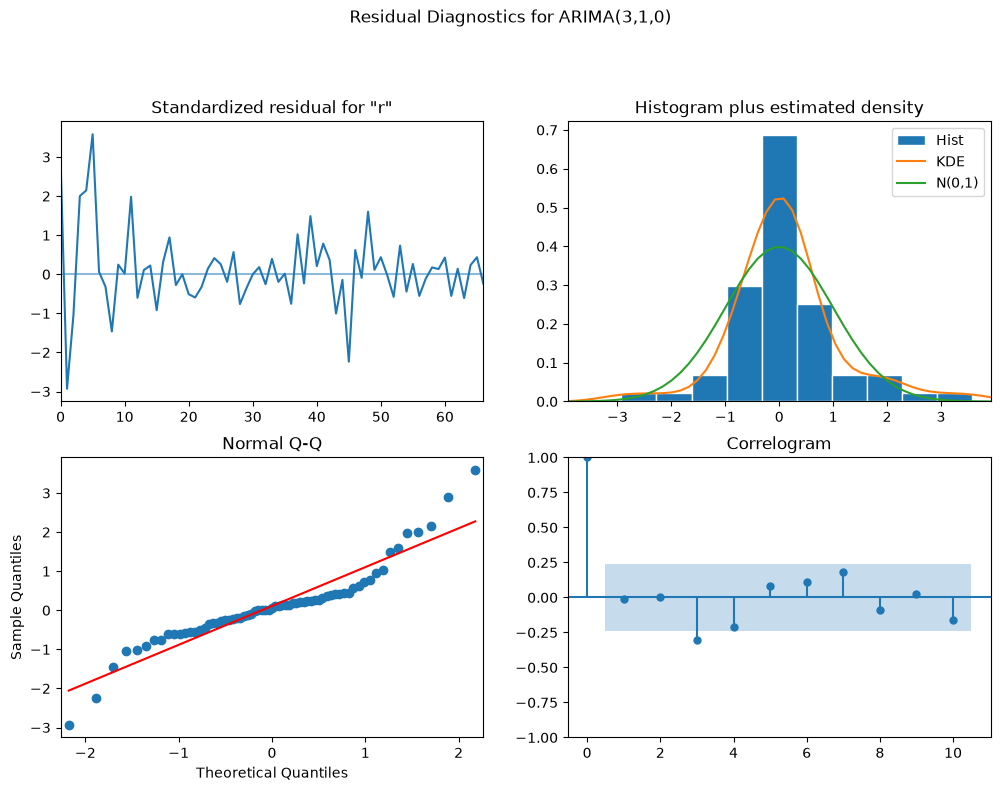

In [ ]:
# Residual diagnostics for ARIMA(3,1,0)
fitted_310.plot_diagnostics(figsize=(12, 8))

plt.suptitle("Residual Diagnostics for ARIMA(3,1,0)", y=1.02)
plt.show()

Since ARIMA(3,1,0) still has significant autocorrelation at Lag 3, increasing the AR order did not solve the problem. Let's test ARIMA(2,1,1) next. This adds a moving-average component, which may capture the remaining error relationship.

### 4.5 Third time is the charm

ARIMA(2,1,1)
AIC: 148.08
BIC: 156.9


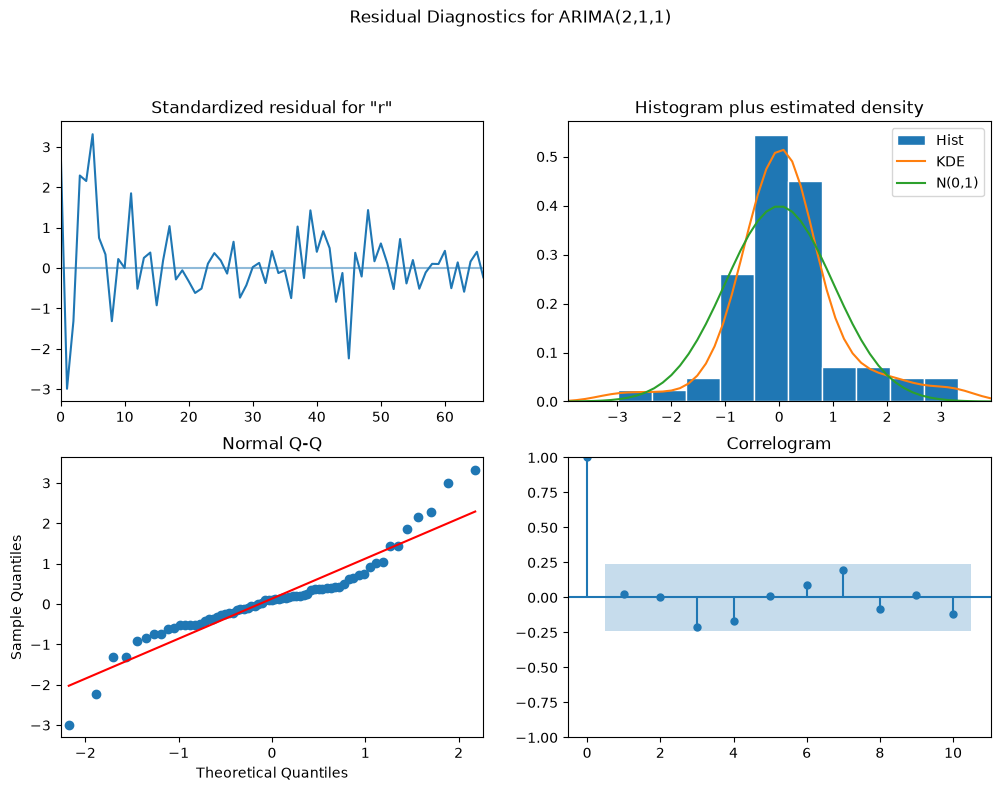

In [ ]:
# Fit ARIMA(2,1,1)
model_211 = ARIMA(series, order=(2, 1, 1))
fitted_211 = model_211.fit()

print("ARIMA(2,1,1)")
print("AIC:", round(fitted_211.aic, 2))
print("BIC:", round(fitted_211.bic, 2))

# Residual diagnostics for ARIMA(2,1,1)
fitted_211.plot_diagnostics(figsize=(12, 8))

plt.suptitle("Residual Diagnostics for ARIMA(2,1,1)", y=1.02)
plt.show()

The residuals fluctuate randomly around zero with no clear trend or changing variance. The Q-Q plot shows that most residuals follow the expected normal pattern, although there are some deviations at the extreme ends. Most importantly, the residual ACF shows that the spikes are within the confidence interval, meaning there is no significant remaining autocorrelation. Overall, the ARIMA(2,1,1) model has captured the main patterns in the series reasonably well, and the residuals behave approximately like white noise.

**We will now compare the AIC and BIC values with the other candidate models to make the final model selection.**

In [ ]:
# Compare ARIMA(2,1,1) with our previous best candidates

print("ARIMA(2,1,0)")
print("AIC:", round(best_model.aic, 2))
print("BIC:", round(best_model.bic, 2))

print("\nARIMA(3,1,0)")
print("AIC:", round(fitted_310.aic, 2))
print("BIC:", round(fitted_310.bic, 2))

print("\nARIMA(2,1,1)")
print("AIC:", round(fitted_211.aic, 2))
print("BIC:", round(fitted_211.bic, 2))

ARIMA(2,1,0)
AIC: 148.88
BIC: 155.5

ARIMA(3,1,0)
AIC: 148.58
BIC: 157.4

ARIMA(2,1,1)
AIC: 148.08
BIC: 156.9


**Final model selection**

ARIMA(2,1,1) was selected as the final model because it achieved the lowest AIC (148.08) among the tested models, while its residual diagnostics showed no significant remaining autocorrelation. Although ARIMA(2,1,0) had a slightly lower BIC, ARIMA(2,1,1) provided the better overall balance between model fit and residual behavior.

### 4.6 Stationarity test on Our final model


In [ ]:
# ADF test on ARIMA(2,1,1) residuals
residuals = fitted_211.resid.dropna()

adf_result = adfuller(residuals)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.134167687139332
p-value: 0.0008499619584003096


### Stationarity Test

The ADF test produced a **p-value of 0.00085**, which is below 0.05. This allowus to conclude that the **ARIMA(2,1,1) residuals are stationary**. Supporting the adequacy of the selected ARIMA(2,1,1) model.


## **Step 5: Forecasting and Reflection**

### 5.1 Model Evaluation

We will split the time series into training and testing data, forecast the test period, and evaluate the model using MAE, RMSE, and MAPE.

In [ ]:
# Make sure the index is a proper datetime index
series = monthly_avg_rating.copy()
series.index = pd.to_datetime(series.index)

# Remove missing values
series = series.dropna()

# Create a regular monthly index
series = series.asfreq('ME')

# Split into training and testing data
train_size = int(len(series) * 0.8)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

# Fit ARIMA(2,1,1)
model = ARIMA(train, order=(2, 1, 1))
fitted_model = model.fit()

# Forecast the test period
forecast = fitted_model.get_forecast(steps=len(test)).predicted_mean

# Make sure forecast uses the same index as test
forecast.index = test.index

# Evaluate the forecast
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("\nForecast Evaluation:")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("MAPE:", round(mape, 2), "%")

Training observations: 136
Testing observations: 35



Forecast Evaluation:
MAE: 0.3547
RMSE: 0.423
MAPE: 8.6 %


The model's predictions were off by about 0.35 rating points on average. The 8.6% MAPE indicates relatively good forecasting accuracy, meaning the model was reasonably effective at predicting monthly customer ratings.

### 5.2 Forecast Plot

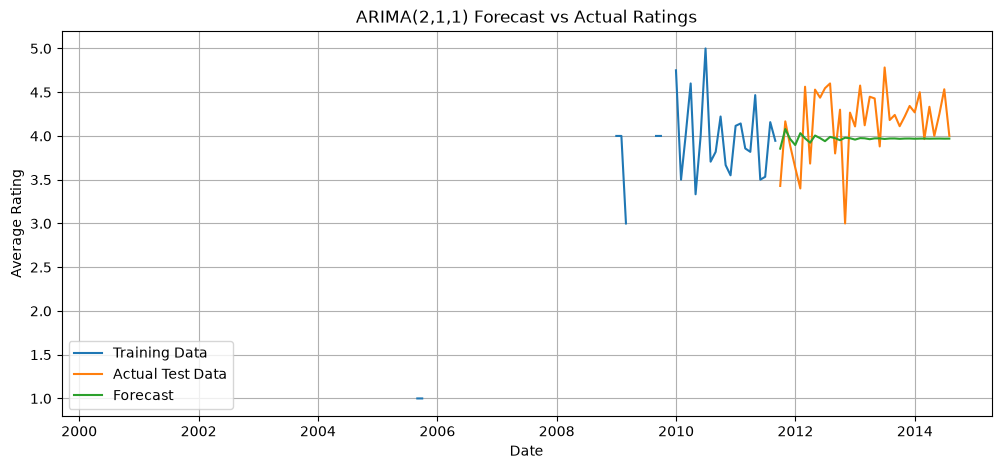

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(forecast, label="Forecast")

plt.title("ARIMA(2,1,1) Forecast vs Actual Ratings")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(True)

plt.show()

### ARIMA(2,1,1) Forecast Evaluation

This line graph compares the **ARIMA(2,1,1) forecast with the actual customer ratings** during the test period.

* **Training Data:** The blue line shows the historical ratings used to train the model, with noticeable month-to-month fluctuations.
* **Actual Test Data:** The orange line shows the actual ratings during the test period, which continue to fluctuate with several sharp increases and decreases.
* **Forecast:** The green line represents the model's predictions. The forecast becomes relatively flat because **ARIMA is a non-seasonal model and does not explicitly account for the yearly seasonal pattern identified during decomposition**. As the forecast moves further into the future, it therefore converges toward the expected level rather than reproducing the monthly ups and downs.
* **Model Evaluation:** The model captures the general level of the ratings but struggles to reproduce short-term fluctuations and seasonal patterns. This suggests that **including seasonal components may improve the forecasting performance**.


### 5.3 Seasonal ARIMA (SARIMA)

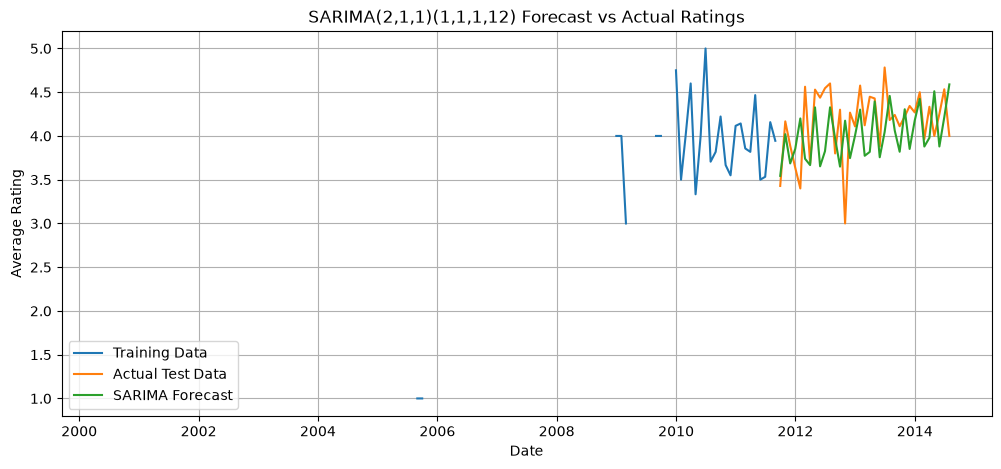

In [ ]:
# Fit SARIMA(2,1,1)(1,1,1,12) with yearly seasonality
sarima_model = SARIMAX(
    train,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

fitted_sarima = sarima_model.fit(disp=False)

# Forecast the test period
sarima_forecast = fitted_sarima.get_forecast(
    steps=len(test)
).predicted_mean

# Use the same index as the test data
sarima_forecast.index = test.index

# Plot SARIMA forecast against actual values
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data")
plt.plot(sarima_forecast, label="SARIMA Forecast")

plt.title("SARIMA(2,1,1)(1,1,1,12) Forecast vs Actual Ratings")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(True)

plt.show()

### SARIMA Forecast Evaluation

This line graph compares the **SARIMA(2,1,1)(1,1,1,12) forecast with the actual customer ratings** during the test period.

* **Training & Test Data:** The blue training line and orange test line show the historical and actual ratings, which continue to fluctuate considerably over time.
* **SARIMA Forecast:** The green line shows the SARIMA predictions. Unlike the ARIMA forecast, it follows a more noticeable repeating pattern because the model includes a **12-month seasonal component**.
* **Model Performance:** The seasonal component allows SARIMA to capture some of the recurring yearly patterns that the non-seasonal ARIMA model could not capture.


### 5.4 Future Rating Trend
Since we already have the fitted SARIMA model, we can forecast, for example, the next 12 months and plot the predicted ratings with confidence intervals. That gives you an evidence-based future trend.

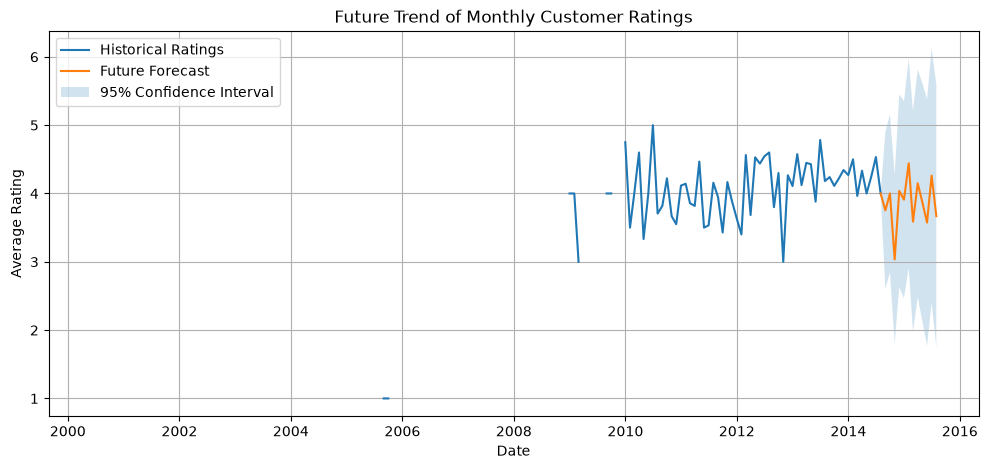

In [ ]:

# Make sure the series has a proper monthly datetime index
series = monthly_avg_rating.copy()
series.index = pd.to_datetime(series.index)
series = series.dropna().asfreq('ME')

# Fit SARIMA(2,1,1)(1,1,1,12) using the full historical series
sarima_model = SARIMAX(
    series,
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

fitted_sarima = sarima_model.fit(disp=False)

# Forecast the next 12 months
future_forecast = fitted_sarima.get_forecast(steps=12)

future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# Add the last historical point so the lines meet
last_date = series.index[-1]
last_value = series.iloc[-1]

forecast_plot = pd.concat([
    pd.Series([last_value], index=[last_date]),
    future_mean
])

lower_ci = pd.concat([
    pd.Series([last_value], index=[last_date]),
    future_ci.iloc[:, 0]
])

upper_ci = pd.concat([
    pd.Series([last_value], index=[last_date]),
    future_ci.iloc[:, 1]
])

# Plot historical data and future forecast
plt.figure(figsize=(12, 5))

plt.plot(
    series.index,
    series,
    label="Historical Ratings"
)

plt.plot(
    forecast_plot.index,
    forecast_plot,
    label="Future Forecast"
)

plt.fill_between(
    forecast_plot.index,
    lower_ci,
    upper_ci,
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Future Trend of Monthly Customer Ratings")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.grid(True)

plt.show()

### Future Trend of Monthly Customer Ratings

The SARIMA model forecasts that monthly customer ratings will remain **relatively stable over the next 12 months**, with the predicted values staying around the current average rating. The forecast also shows some **recurring seasonal variation**, reflecting the 12-month seasonal pattern identified earlier.

However, the **95% confidence interval widens as the forecast moves further into the future**, indicating increasing uncertainty. This means the model is more confident about the near-term predictions than the later forecasts.

**The model suggests that customer ratings are likely to remain around their current level rather than showing a strong upward or downward trend, although future ratings may vary due to seasonal effects and other factors not included in the model.**


## 5.5 Reflection on Model Parameters and Future Improvements

The model parameters had a direct effect on how well the time series was modeled.

### Model Parameters

* **Differencing order (d):** The original series was non-stationary based on the ADF test, so we used **d = 1** to difference the series once and remove the underlying trend. Using no differencing would leave the series non-stationary, while excessive differencing could remove useful information.

* **AR (p) and MA (q):** These parameters helped the model capture relationships between previous ratings and previous forecasting errors. After comparing different combinations, **ARIMA(2,1,1)** provided the best overall fit based on AIC and residual diagnostics.

* **Seasonality:** The ARIMA forecast became relatively flat because it did not explicitly account for the yearly seasonal pattern identified during decomposition. Therefore, **SARIMA(2,1,1)(1,1,1,12)** was introduced to incorporate the 12-month seasonal cycle and capture recurring yearly patterns.

### Future Improvements

Several improvements could make the forecasting process more accurate:

* Test different **seasonal AR, differencing, and MA parameters** and compare their **MAE, RMSE, and MAPE** to identify the most accurate model.

* Include additional variables such as **product categories, review volume, review length, and sentiment scores** to provide more information about changes in customer ratings.

* Explore **machine learning models** that may capture complex relationships that traditional time series models cannot.

* Use **more recent data** to make future forecasts more relevant to current customer behavior.

* Include external factors such as **price changes, promotions, and major product updates** to better understand what drives customer ratings up or down.

